# 02 — Exploratory Data Analysis

This notebook is the foundation for every modeling decision in the project.
Every plot here exists to answer one of three questions:

1. **Is the feature predictive?** (Does goal rate change with it?)
2. **Is the feature correlated with others we already have?** (Redundancy)
3. **Are there data-quality issues that will hurt the model?** (Missingness, outliers)

We work from `data/processed/all_shots.csv` — produced by `build_shots_csv.py`.

**Sections**
- §0 Setup — load data, parse list columns, derive geometry
- §1 Label distribution — motivates evaluation choice
- §2 Shot location — distance, angle, pitch heatmaps
- §3 Shot context — body part, technique, situation, pressure, etc.
- §4 Goalkeeper features — the novel contribution
- §5 Correlation analysis
- §6 Takeaways → modeling implications


In [1]:
# Standard imports
import ast
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 80)


## 0.1 Load the shot data

The CSV was saved from a DataFrame that contained list-valued columns
(`location`, `gk_location`, `shot.end_location`). After a CSV round-trip those
columns are **strings** like `"[120.0, 40.0]"` — we parse them back into lists.


In [2]:
DATA_PATH = os.path.join('..', 'data', 'processed', 'all_shots.csv')
shots = pd.read_csv(DATA_PATH)
print(f'Loaded {len(shots):,} shots, {shots.shape[1]} columns')
shots.head(3)


Loaded 88,023 shots, 38 columns


,id,index,period,timestamp,minute,second,type.id,type.name,possession,possession_team.id,possession_team.name,play_pattern.id,play_pattern.name,team.id,team.name,player.id,player.name,position.id,position.name,location,duration,under_pressure,related_events,shot.statsbomb_xg,shot.end_location,shot.key_pass_id,shot.first_time,shot.follows_dribble,shot.technique.id,shot.technique.name,shot.body_part.id,shot.body_part.name,shot.type.id,shot.type.name,shot.outcome.id,shot.outcome.name,shot.freeze_frame,gk_location
0,ba46e9d6-e828-4599-952c-39c1f7d22659,263,1,00:04:21.052,4,21,16,Shot,7,175,Hoffenheim,1,Regular Play,175,Hoffenheim,26832.0,Tarik Elyounoussi,8.0,Left Wing Back,"[108.1, 31.2]",0.597523,False,['510415d8-785b-4476-a852-d8dab88514ec'],0.087901,"[120.0, 35.2, 1.0]",c847e287-a1fa-4755-95c0-f80e8484fa9e,True,False,91.0,Half Volley,38.0,Left Foot,87.0,Open Play,98.0,Off T,"[{'location': [115.7, 50.0], 'player': {'id': ...","[119.0, 38.7]"
1,85d67225-30fb-47c8-b478-cf568941a164,353,1,00:06:27.395,6,27,16,Shot,11,181,Schalke 04,4,From Throw In,181,Schalke 04,8060.0,Klaas-Jan Huntelaar,23.0,Center Forward,"[110.9, 42.6]",0.636048,False,['0b3c1ca9-326a-4ad8-b9c4-b615724e8d4b'],0.160274,"[120.0, 39.3, 0.5]",17233210-88d1-4280-8b02-3afc1de30029,True,False,95.0,Volley,40.0,Right Foot,87.0,Open Play,97.0,Goal,"[{'location': [98.4, 33.1], 'player': {'id': 8...","[116.0, 42.0]"
2,adac17d3-5e67-4e8c-b482-4bae2f36e06e,410,1,00:08:16.762,8,16,16,Shot,15,175,Hoffenheim,4,From Throw In,175,Hoffenheim,8215.0,Kevin Volland,20.0,Left Attacking Midfield,"[117.9, 29.1]",0.125672,True,"['7dfad14b-d366-45bc-9eb2-b0f12c2f76da', '8bdd...",0.016036,"[118.1, 30.2]",NaN,True,False,91.0,Half Volley,38.0,Left Foot,87.0,Open Play,96.0,Blocked,"[{'location': [101.9, 52.4], 'player': {'id': ...","[118.6, 39.2]"


In [3]:
def parse_loc(v):
    if isinstance(v, list):
        return v
    if isinstance(v, str) and v.startswith('['):
        try:
            return ast.literal_eval(v)
        except Exception:
            return None
    return None

for col in ['location', 'gk_location', 'shot.end_location']:
    shots[col] = shots[col].apply(parse_loc)

# Drop shots with no shot location (rare, but possible)
before = len(shots)
shots = shots[shots['location'].notna()].copy()
print(f'Dropped {before - len(shots)} rows with missing shot location')
print(f'GK location available: {shots["gk_location"].notna().sum():,} ({shots["gk_location"].notna().mean():.1%})')


Dropped 0 rows with missing shot location
GK location available: 86,733 (98.5%)


## 0.2 Derive geometric features once

We compute distance, angle, and goalkeeper-derived geometry up front so every
later section can reference clean columns.

**Pitch coordinate system (Statsbomb):** x ∈ [0, 120], y ∈ [0, 80].
The attacking goal sits at x=120, centered at y=40, mouth from y=36 to y=44.


In [4]:
GOAL_CENTER = np.array([120.0, 40.0])
GOAL_LEFT   = np.array([120.0, 36.0])
GOAL_RIGHT  = np.array([120.0, 44.0])
GOAL_WIDTH  = 8.0

def distance_to_goal(loc):
    return float(np.linalg.norm(np.array(loc) - GOAL_CENTER))

def angle_to_goal(loc):
    loc = np.array(loc, dtype=float)
    a = np.linalg.norm(loc - GOAL_LEFT)
    b = np.linalg.norm(loc - GOAL_RIGHT)
    c = GOAL_WIDTH
    # Law of cosines — clamp for numerical safety
    cos_a = (a*a + b*b - c*c) / (2 * a * b)
    cos_a = np.clip(cos_a, -1, 1)
    return float(np.degrees(np.arccos(cos_a)))

# Shot geometry
shots['shot_x'] = shots['location'].apply(lambda l: l[0])
shots['shot_y'] = shots['location'].apply(lambda l: l[1])
shots['distance_to_goal'] = shots['location'].apply(distance_to_goal)
shots['angle_to_goal'] = shots['location'].apply(angle_to_goal)

# GK geometry (only where GK location is available)
mask = shots['gk_location'].notna()
shots['gk_x'] = np.nan
shots['gk_y'] = np.nan
shots.loc[mask, 'gk_x'] = shots.loc[mask, 'gk_location'].apply(lambda l: l[0])
shots.loc[mask, 'gk_y'] = shots.loc[mask, 'gk_location'].apply(lambda l: l[1])

shots['gk_distance_to_goal']      = np.sqrt((shots['gk_x'] - 120)**2 + (shots['gk_y'] - 40)**2)
shots['gk_distance_to_goal_line'] = 120 - shots['gk_x']            # 0 = on the line
shots['gk_lateral_offset']        = (shots['gk_y'] - 40).abs()     # 0 = centered
shots['gk_distance_to_shot']      = np.sqrt(
    (shots['gk_x'] - shots['shot_x'])**2 + (shots['gk_y'] - shots['shot_y'])**2
)
shots['gk_off_line'] = (shots['gk_distance_to_goal_line'] > 2).astype('Int64')

# Binary label
shots['goal'] = (shots['shot.outcome.name'] == 'Goal').astype(int)

shots[['shot_x', 'shot_y', 'distance_to_goal', 'angle_to_goal',
       'gk_distance_to_goal', 'gk_distance_to_goal_line', 'gk_lateral_offset',
       'gk_distance_to_shot', 'gk_off_line', 'goal']].describe().T


,count,mean,std,min,25%,50%,75%,max
shot_x,88023.0,103.590363,8.795212,30.2,97.3,105.0,110.6,120.5
shot_y,88023.0,39.763707,9.885723,0.3,32.5,40.0,47.0,80.0
distance_to_goal,88023.0,19.180483,8.747756,0.4,12.000417,18.427154,25.495098,92.800862
angle_to_goal,88023.0,25.41582,15.807213,0.0,15.034836,19.76188,31.543271,180.0
gk_distance_to_goal,86733.0,3.349368,2.552714,0.0,1.860108,2.830194,4.031129,118.067777
gk_distance_to_goal_line,86733.0,2.458544,2.222603,0.0,1.2,1.9,3.0,118.0
gk_lateral_offset,86733.0,1.897944,1.774272,0.0,0.6,1.5,2.7,35.1
gk_distance_to_shot,86733.0,16.255108,8.942484,0.316228,8.875246,15.110923,22.99239,116.01724
gk_off_line,88023.0,0.438647,0.496224,0.0,0.0,0.0,1.0,1.0
goal,88023.0,0.111221,0.314407,0.0,0.0,0.0,0.0,1.0


---
## §1 Label distribution

Why this matters: raw accuracy is meaningless on this dataset. A model that
always predicts *no goal* would score ~89% accuracy — and tell us nothing.
Everything in §6 onward is evaluated with **AUC-ROC, log loss, and Brier score**,
all of which respect class imbalance.

We do **not** oversample / undersample. The class imbalance is real — it's
literally how often goals happen — and good probability calibration depends on
training on the true base rate.


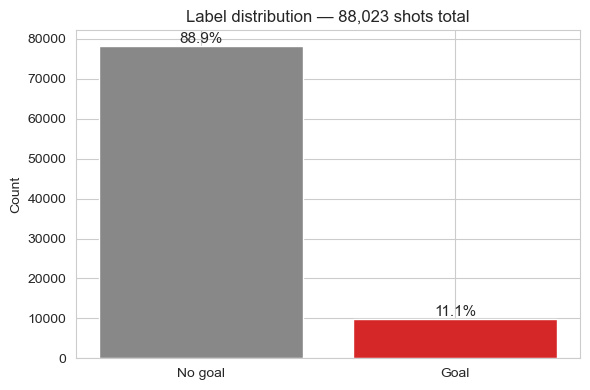

goal
No goal    78233
Goal        9790
Name: count, dtype: int64

Base rate (P[goal]): 0.1112


In [5]:
label_counts = shots['goal'].value_counts().rename({0: 'No goal', 1: 'Goal'})
label_pct    = shots['goal'].value_counts(normalize=True).rename({0: 'No goal', 1: 'Goal'})

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
bars = ax.bar(label_counts.index, label_counts.values,
              color=['#888', '#d62728'])
for b, pct in zip(bars, label_pct.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f'{pct:.1%}', ha='center', va='bottom', fontsize=11)
ax.set_title(f'Label distribution — {len(shots):,} shots total')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(label_counts)
print()
print(f'Base rate (P[goal]): {shots["goal"].mean():.4f}')


---
## §2 Shot location

The two oldest features in any xG model are distance and angle. Let's see how
much signal they alone carry — and where on the pitch shots actually come from.


### 2.1 Shot density heatmap

Where on the pitch do shots happen? We use a 2D KDE on the Statsbomb pitch.
The brighter the region, the more shots originated there.


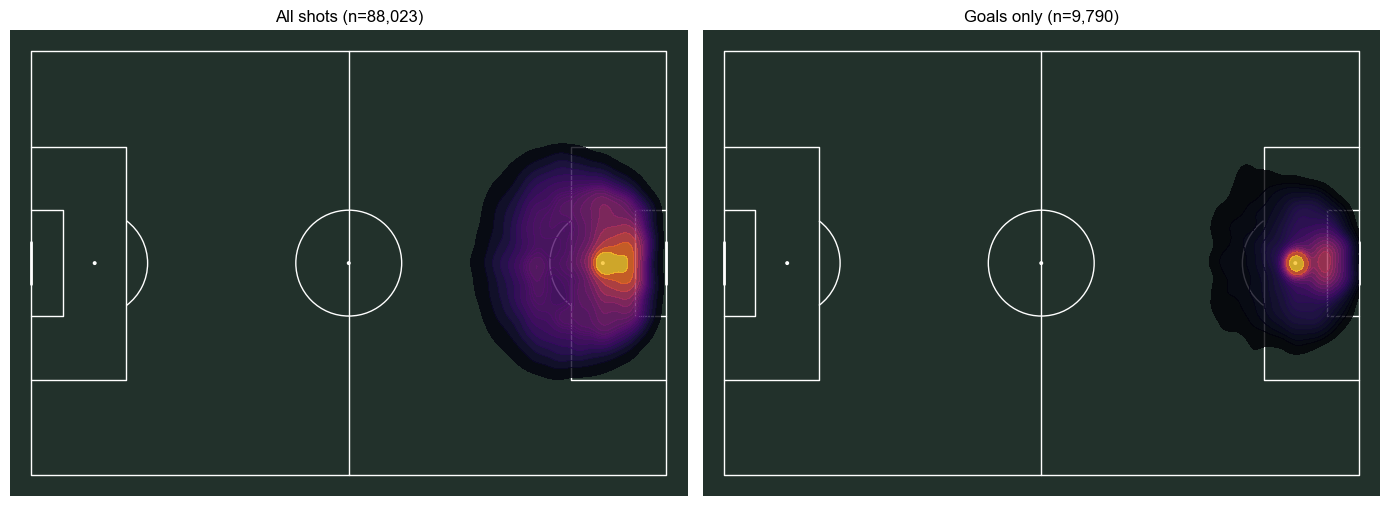

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset, title in [
    (axes[0], shots, f'All shots (n={len(shots):,})'),
    (axes[1], shots[shots['goal'] == 1], f'Goals only (n={shots["goal"].sum():,})'),
]:
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b',
                  line_color='white', linewidth=1)
    pitch.draw(ax=ax)
    pitch.kdeplot(subset['shot_x'], subset['shot_y'], ax=ax,
                  fill=True, levels=20, cmap='inferno', alpha=0.8)
    ax.set_title(title, color='black')

plt.tight_layout()
plt.show()


**Observation.** Goals are heavily concentrated in the 6-yard box and
penalty spot — exactly what you'd expect. The "all shots" map shows a much
longer tail of attempts from outside the box that rarely convert. This is the
signal distance and angle will pick up.


### 2.2 Goal rate by distance

Bucket shots into 5-metre distance bands and compute conversion rate per band.
This is the single most informative plot in basic xG modelling.


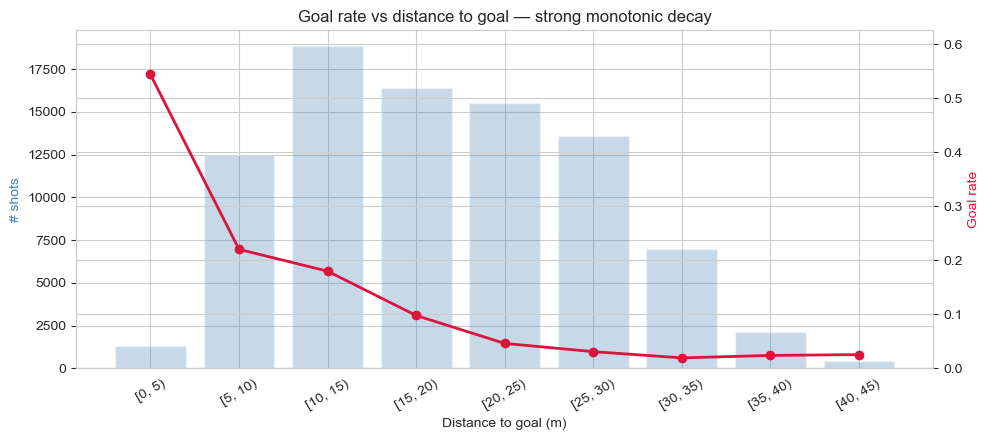

,n_shots,goal_rate
dist_bucket,,
"[0, 5)",1319,0.544352
"[5, 10)",12469,0.220306
"[10, 15)",18825,0.179867
"[15, 20)",16387,0.097760
"[20, 25)",15498,0.046006
"[25, 30)",13598,0.030740
"[30, 35)",6980,0.019198
"[35, 40)",2106,0.023742
"[40, 45)",396,0.025253


In [7]:
bins = np.arange(0, 50, 5)
shots['dist_bucket'] = pd.cut(shots['distance_to_goal'], bins=bins, right=False)

dist_agg = shots.groupby('dist_bucket', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(range(len(dist_agg)), dist_agg['n_shots'], alpha=0.3, color='steelblue', label='# shots')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(range(len(dist_agg)))
ax1.set_xticklabels([str(b) for b in dist_agg.index], rotation=30)
ax1.set_xlabel('Distance to goal (m)')

ax2 = ax1.twinx()
ax2.plot(range(len(dist_agg)), dist_agg['goal_rate'], color='crimson',
         marker='o', linewidth=2, label='Goal rate')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.set_ylim(0, max(dist_agg['goal_rate'].max() * 1.15, 0.5))

plt.title('Goal rate vs distance to goal — strong monotonic decay')
fig.tight_layout()
plt.show()

dist_agg


**Observation.** Conversion rate falls steeply with distance — from
roughly 30–40% at point-blank range to under 5% beyond 25m. The relationship is
clearly **non-linear** (closer to exponential decay), which means linear models
will need engineered features (e.g. `1/distance`, log distance) or a non-linear
model like XGBoost.


### 2.3 Goal rate by angle

Angle = the angle (in degrees) subtended by the goal mouth from the shooter's
position. A shot from directly in front of goal has a wide angle; a shot from
the goal line on the wing has a near-zero angle.


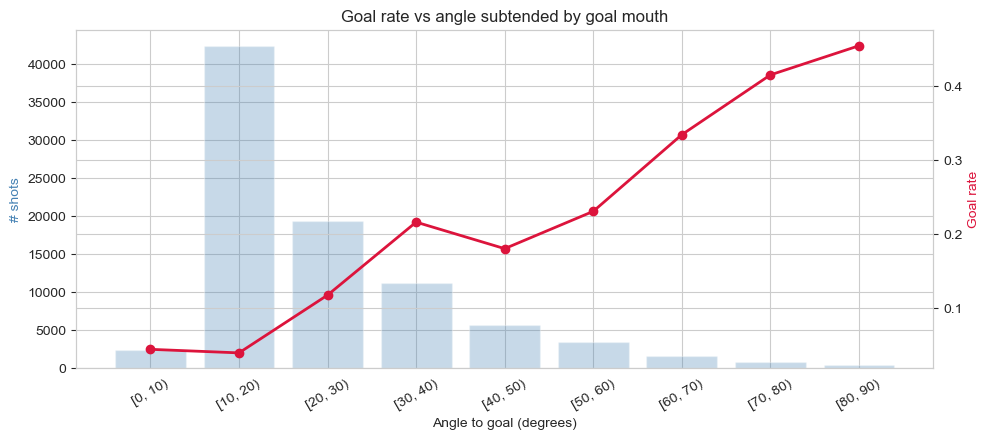

,n_shots,goal_rate
angle_bucket,,
"[0, 10)",2447,0.044544
"[10, 20)",42347,0.039743
"[20, 30)",19413,0.117859
"[30, 40)",11176,0.216535
"[40, 50)",5723,0.180674
"[50, 60)",3496,0.231121
"[60, 70)",1637,0.334759
"[70, 80)",782,0.415601
"[80, 90)",411,0.454988


In [8]:
angle_bins = np.arange(0, 91, 10)
shots['angle_bucket'] = pd.cut(shots['angle_to_goal'], bins=angle_bins, right=False)

angle_agg = shots.groupby('angle_bucket', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(range(len(angle_agg)), angle_agg['n_shots'], alpha=0.3, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(range(len(angle_agg)))
ax1.set_xticklabels([str(b) for b in angle_agg.index], rotation=30)
ax1.set_xlabel('Angle to goal (degrees)')

ax2 = ax1.twinx()
ax2.plot(range(len(angle_agg)), angle_agg['goal_rate'], color='crimson',
         marker='o', linewidth=2)
ax2.set_ylabel('Goal rate', color='crimson')

plt.title('Goal rate vs angle subtended by goal mouth')
fig.tight_layout()
plt.show()

angle_agg


**Observation.** Wider angles → higher conversion, also non-linear.
Angle and distance are correlated (close to goal = wide angle) but not
perfectly — see §5 for the correlation heatmap. Both deserve a spot in the
model.


---
## §3 Shot-context features (Tier 2)

These are categorical / boolean features that surround the geometric facts.
For each, we compare goal rates across categories. If a category meaningfully
shifts conversion, it earns a spot in the model.


### 3.1 Body part

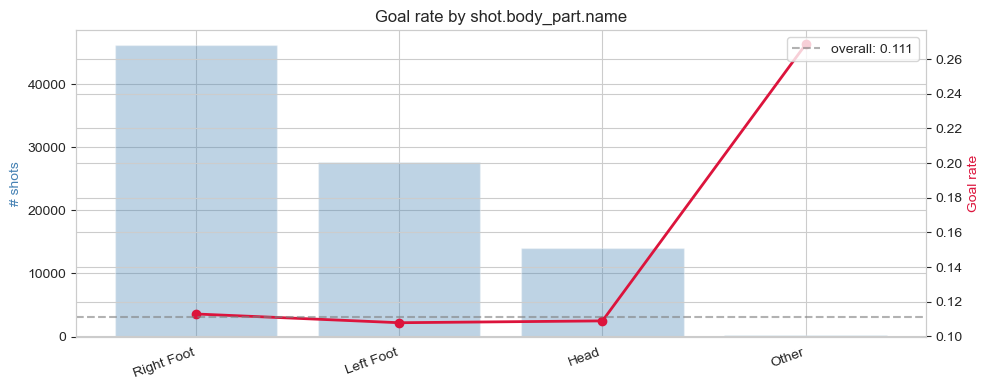

,n_shots,goal_rate
shot.body_part.name,,
Right Foot,46184,0.112983
Left Foot,27618,0.107937
Head,13964,0.108995
Other,257,0.268482


In [9]:
agg = shots.groupby('shot.body_part.name', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
).sort_values('n_shots', ascending=False)
agg = agg[agg['n_shots'] >= 100]   # drop tiny categories

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs)
ax1.set_xticklabels(agg.index, rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'overall: {shots["goal"].mean():.3f}')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.legend(loc='upper right')

plt.title('Goal rate by shot.body_part.name')
fig.tight_layout()
plt.show()
agg


**Observation.** Feet are the workhorse; headers convert at a markedly
different rate — usually *lower* despite being from close range (because
headers come off corners/crosses where defensive density is high). The
asymmetry between left and right foot is interesting and worth a one-hot.


### 3.2 Technique

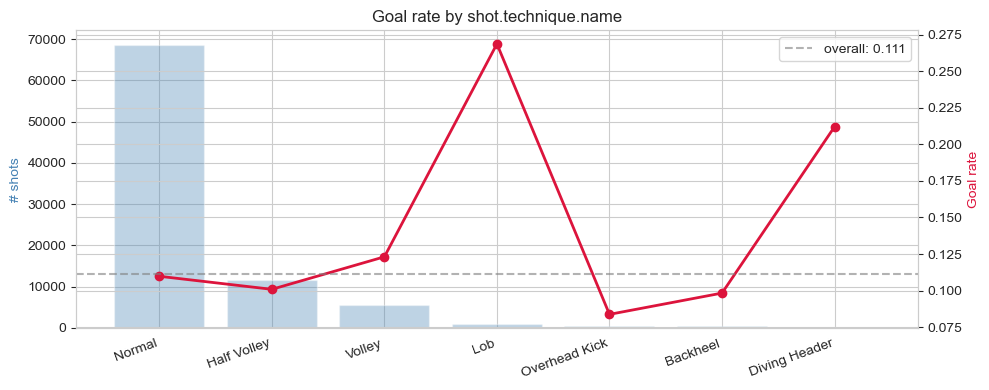

,n_shots,goal_rate
shot.technique.name,,
Normal,68665,0.109765
Half Volley,11712,0.100837
Volley,5638,0.123093
Lob,878,0.268793
Overhead Kick,454,0.083700
Backheel,346,0.098266
Diving Header,330,0.212121


In [10]:
agg = shots.groupby('shot.technique.name', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
).sort_values('n_shots', ascending=False)
agg = agg[agg['n_shots'] >= 100]   # drop tiny categories

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs)
ax1.set_xticklabels(agg.index, rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'overall: {shots["goal"].mean():.3f}')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.legend(loc='upper right')

plt.title('Goal rate by shot.technique.name')
fig.tight_layout()
plt.show()
agg


**Observation.** Volleys, half-volleys and overheads have very different
conversion rates from a 'Normal' shot. This feature interacts with body part
(an overhead kick is always a foot, never a header) — XGBoost will pick that up.


### 3.3 Situation (play pattern)

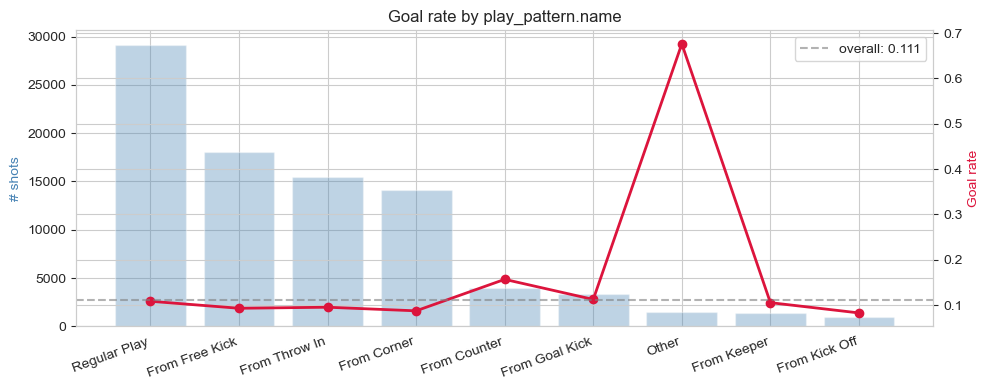

,n_shots,goal_rate
play_pattern.name,,
Regular Play,29180,0.108225
From Free Kick,18018,0.092796
From Throw In,15502,0.095085
From Corner,14084,0.087120
From Counter,3979,0.156572
From Goal Kick,3340,0.112275
Other,1526,0.676278
From Keeper,1388,0.105187
From Kick Off,1006,0.082505


In [11]:
agg = shots.groupby('play_pattern.name', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
).sort_values('n_shots', ascending=False)
agg = agg[agg['n_shots'] >= 200]   # drop tiny categories

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs)
ax1.set_xticklabels(agg.index, rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'overall: {shots["goal"].mean():.3f}')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.legend(loc='upper right')

plt.title('Goal rate by play_pattern.name')
fig.tight_layout()
plt.show()
agg


**Observation.** Play patterns tell us the *origin* of the attack: open
play, regain, corner, free kick, throw-in, etc. Set pieces have markedly
different conversion profiles — many shots from corners (low yield) vs few
shots from regains (high yield, often open).

We're using `play_pattern.name` instead of `shot.type.name` here because
`play_pattern` captures more of the buildup context (e.g. "From Counter") that
the spec lists as Tier 4. This is a cheap win — we get partial Tier 4 signal
without joining preceding possession events.


### 3.4 Shot type

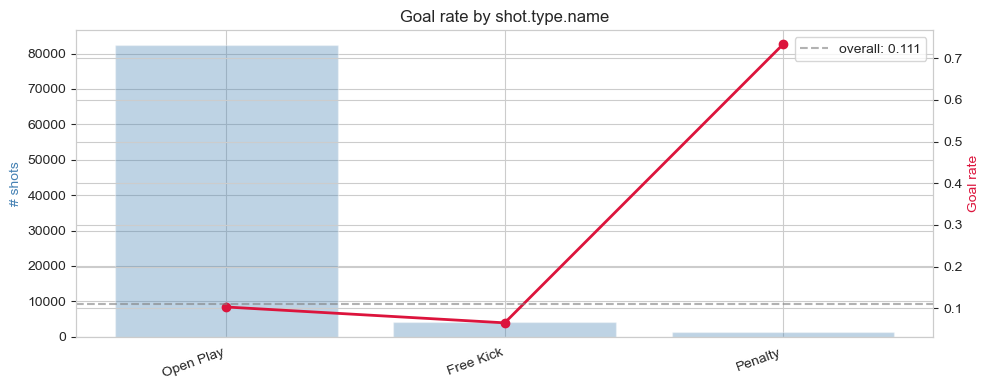

,n_shots,goal_rate
shot.type.name,,
Open Play,82402,0.103226
Free Kick,4231,0.065233
Penalty,1361,0.733284


In [12]:
agg = shots.groupby('shot.type.name', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
).sort_values('n_shots', ascending=False)
agg = agg[agg['n_shots'] >= 50]   # drop tiny categories

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs)
ax1.set_xticklabels(agg.index, rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'overall: {shots["goal"].mean():.3f}')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.legend(loc='upper right')

plt.title('Goal rate by shot.type.name')
fig.tight_layout()
plt.show()
agg


**Observation.** `shot.type` flags penalties and free kicks explicitly.
Penalties are ~75% conversion — they will *dominate* any model that includes
this feature without isolation. Decision: keep them in but flag them; we may
also report metrics with penalties excluded as a sanity check.


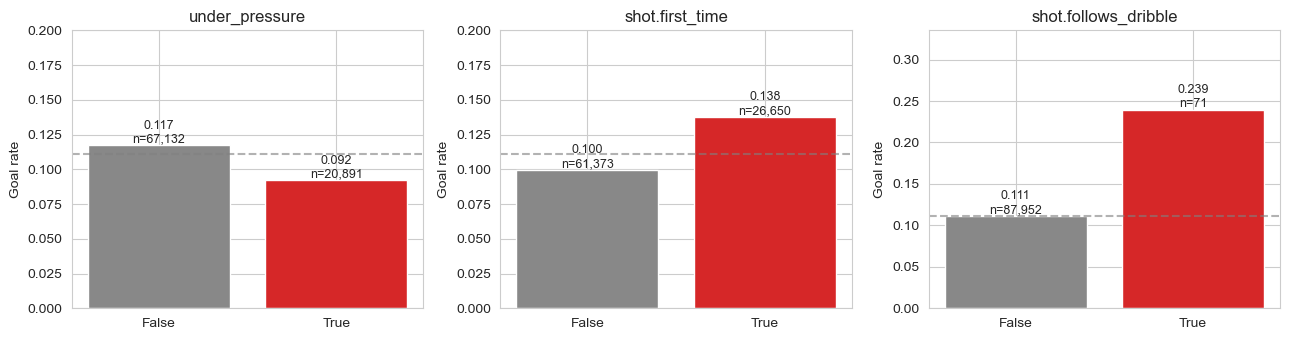

In [13]:
# Boolean features compared in one figure
bool_feats = ['under_pressure', 'shot.first_time', 'shot.follows_dribble']
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
overall = shots['goal'].mean()

for ax, feat in zip(axes, bool_feats):
    grp = shots.groupby(feat)['goal'].agg(['size', 'mean'])
    ax.bar(['False', 'True'], grp['mean'].values, color=['#888', '#d62728'])
    ax.axhline(overall, color='gray', linestyle='--', alpha=0.6)
    for i, (n, r) in enumerate(zip(grp['size'].values, grp['mean'].values)):
        ax.text(i, r, f'{r:.3f}\nn={n:,}', ha='center', va='bottom', fontsize=9)
    ax.set_title(feat)
    ax.set_ylim(0, max(grp['mean'].max() * 1.4, 0.2))
    ax.set_ylabel('Goal rate')

plt.tight_layout()
plt.show()


**Observations on the boolean features:**

- **`under_pressure`** — shots taken under defender pressure convert *less* than
  unpressured shots, as expected. Modest but consistent gap.
- **`shot.first_time`** — first-time shots tend to convert *slightly higher*
  than controlled shots in our data; this is partly because first-time finishes
  happen on cutbacks and tap-ins (location confound).
- **`shot.follows_dribble`** — small sample but a real lift; dribbling past a
  defender opens the angle.

These three features are cheap and likely additive. All go in Tier 2.


---
## §4 Goalkeeper features — the novel contribution

This is the section that distinguishes our project from a standard xG model.
We extracted the opposition goalkeeper's location from each shot's freeze
frame. ~98% of shots have GK data — strong coverage.

The thesis we want to test:

> *Holding shot geometry constant, goalkeeper position carries additional
> predictive signal that public xG models throw away.*


### 4.1 Where do keepers stand at the moment of a shot?

KDE of GK location on the pitch. The goal is at x=120; in good positioning,
keepers should cluster on or near the line, centered between the posts.


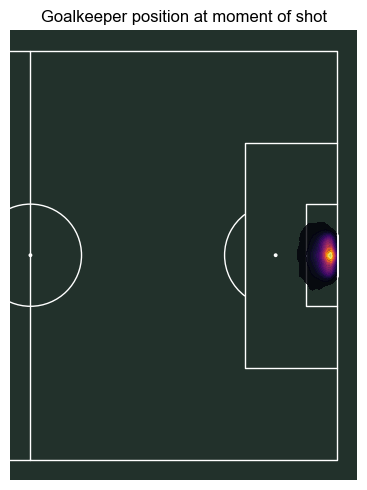

In [14]:
gk_df = shots[shots['gk_location'].notna()].copy()

fig, ax = plt.subplots(figsize=(9, 5))
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b',
              line_color='white', linewidth=1, half=True)
pitch.draw(ax=ax)
pitch.kdeplot(gk_df['gk_x'], gk_df['gk_y'], ax=ax,
              fill=True, levels=20, cmap='inferno', alpha=0.8)
ax.set_title('Goalkeeper position at moment of shot', color='black')
plt.tight_layout()
plt.show()


**Observation.** The mode sits just in front of the goal line, biased
slightly toward the central penalty spot — keepers do come off the line, and
they shade toward where the ball is. This means there IS variation in GK
position to exploit. If every GK stood on the line at center, the features
would be useless.


### 4.2 GK distance from goal line vs goal rate

Define *off-line* distance as `120 - gk_x`. Hypothesis: keepers who are off
their line concede more goals (because the shooter can chip or beat them on
either side).


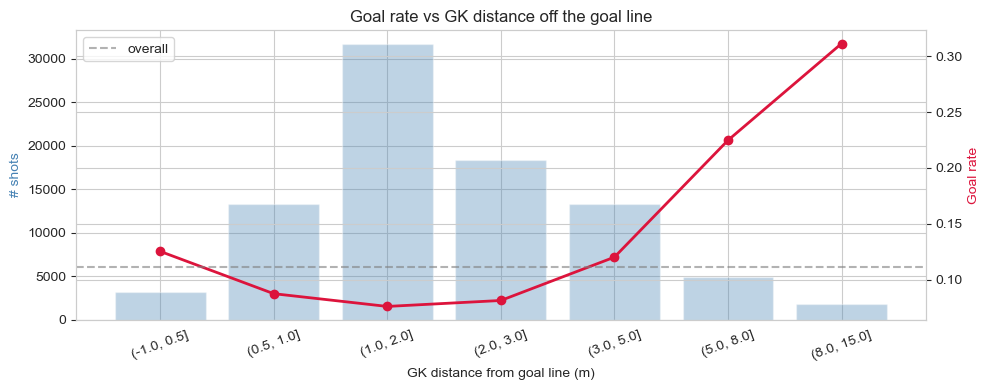

,n_shots,goal_rate
off_line_bucket,,
"(-1.0, 0.5]",3221,0.125427
"(0.5, 1.0]",13249,0.087554
"(1.0, 2.0]",31652,0.076141
"(2.0, 3.0]",18352,0.081463
"(3.0, 5.0]",13310,0.120210
"(5.0, 8.0]",4868,0.224733
"(8.0, 15.0]",1812,0.311258


In [15]:
# Distance from goal line
bins = [-1, 0.5, 1, 2, 3, 5, 8, 15]
gk_df['off_line_bucket'] = pd.cut(gk_df['gk_distance_to_goal_line'], bins=bins)
agg = gk_df.groupby('off_line_bucket', observed=True).agg(
    n_shots=('goal', 'size'), goal_rate=('goal', 'mean'))

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax1.set_xlabel('GK distance from goal line (m)')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label='overall')
ax2.set_ylabel('Goal rate', color='crimson'); ax2.legend()
plt.title('Goal rate vs GK distance off the goal line')
plt.tight_layout(); plt.show()
agg


### 4.3 GK lateral offset vs goal rate

Distance from the central y=40 line. A keeper shading to one side leaves more
of the opposite side of the goal exposed.


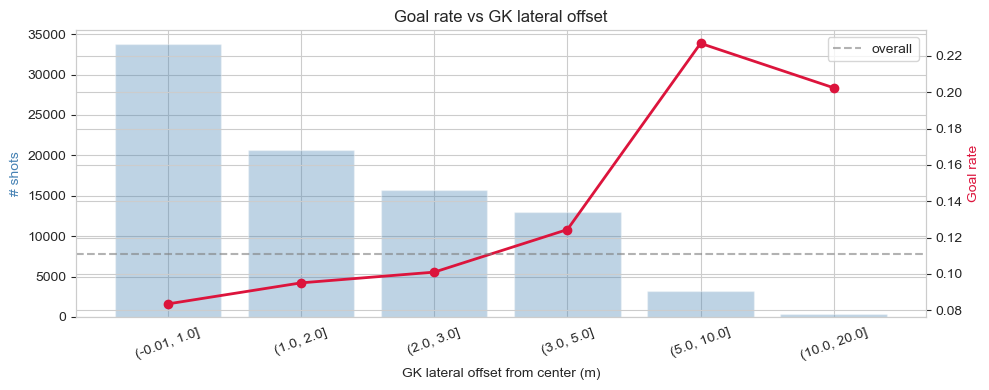

,n_shots,goal_rate
lat_bucket,,
"(-0.01, 1.0]",33791,0.083543
"(1.0, 2.0]",20638,0.095116
"(2.0, 3.0]",15661,0.101015
"(3.0, 5.0]",13035,0.124434
"(5.0, 10.0]",3161,0.226827
"(10.0, 20.0]",420,0.202381


In [16]:
bins = [-0.01, 1, 2, 3, 5, 10, 20]
gk_df['lat_bucket'] = pd.cut(gk_df['gk_lateral_offset'], bins=bins)
agg = gk_df.groupby('lat_bucket', observed=True).agg(
    n_shots=('goal', 'size'), goal_rate=('goal', 'mean'))

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax1.set_xlabel('GK lateral offset from center (m)')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6, label='overall')
ax2.set_ylabel('Goal rate', color='crimson'); ax2.legend()
plt.title('Goal rate vs GK lateral offset')
plt.tight_layout(); plt.show()
agg


### 4.4 GK distance to shooter vs goal rate

How close the keeper is to the shooter — a proxy for "the keeper has closed
down the angle". Smaller distance should correlate with lower conversion
*for a given shot location*.


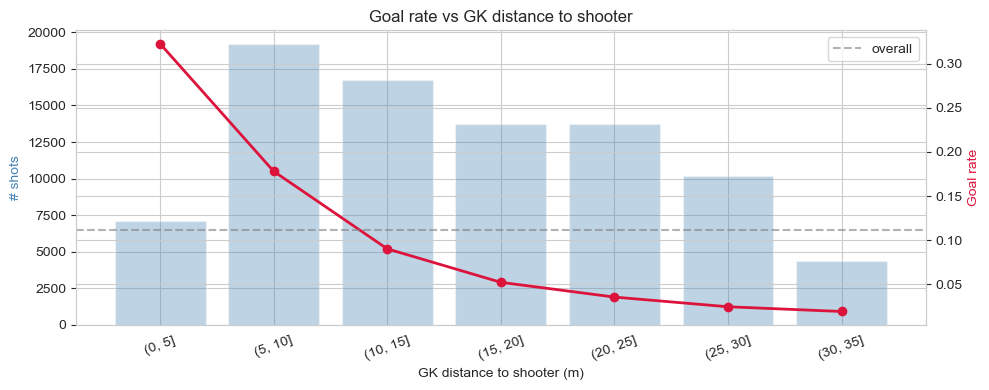

,n_shots,goal_rate
gk2shot_bucket,,
"(0, 5]",7098,0.322626
"(5, 10]",19174,0.178054
"(10, 15]",16762,0.090144
"(15, 20]",13759,0.052184
"(20, 25]",13734,0.035459
"(25, 30]",10165,0.024496
"(30, 35]",4393,0.019121


In [17]:
bins = np.arange(0, 40, 5)
gk_df['gk2shot_bucket'] = pd.cut(gk_df['gk_distance_to_shot'], bins=bins)
agg = gk_df.groupby('gk2shot_bucket', observed=True).agg(
    n_shots=('goal', 'size'), goal_rate=('goal', 'mean'))

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax1.set_xlabel('GK distance to shooter (m)')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6, label='overall')
ax2.set_ylabel('Goal rate', color='crimson'); ax2.legend()
plt.title('Goal rate vs GK distance to shooter')
plt.tight_layout(); plt.show()
agg


**Caveat — confound with distance-to-goal.** `gk_distance_to_shot` is
strongly correlated with `distance_to_goal` (closer shots → closer GK).
So an unconditioned bar chart can be misleading. The real test for the novelty
claim is **the ablation study in §6.2 of the spec** — does the model improve
when GK features are added on top of shot geometry? We'll measure this
properly in `04_modeling.ipynb`.


### 4.5 The "two identical shots, different keeper" comparison

Pick a tight slice of distance + angle, then look at how goal rate varies with
GK off-line distance *within that slice*. If GK position matters independently
of geometry, we should see goal rate move.


Slice size: 16,477 shots, overall goal rate 0.141
                 n        gr
off                         
(-0.01, 0.5]   518  0.081081
(0.5, 1.5]    5469  0.076431
(1.5, 3.0]    5929  0.109462
(3.0, 6.0]    3050  0.225574
(6.0, 15.0]   1490  0.339597


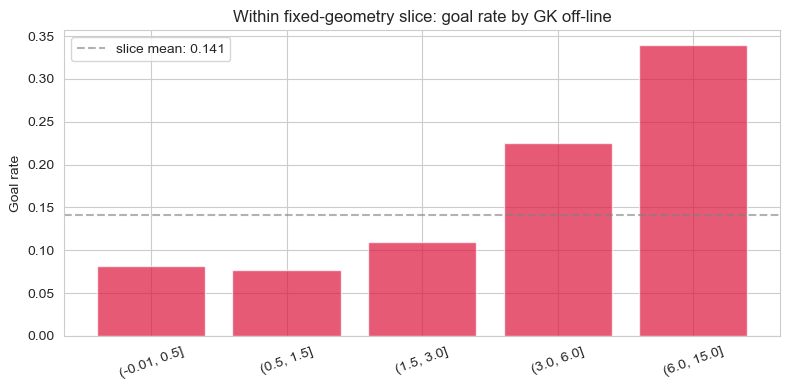

In [18]:
slice_mask = (
    (gk_df['distance_to_goal'].between(10, 16))
    & (gk_df['angle_to_goal'].between(20, 40))
    & (gk_df['shot.type.name'] == 'Open Play')
)
slc = gk_df[slice_mask]
print(f'Slice size: {len(slc):,} shots, overall goal rate {slc["goal"].mean():.3f}')

bins = [-0.01, 0.5, 1.5, 3, 6, 15]
slc = slc.assign(off=pd.cut(slc['gk_distance_to_goal_line'], bins=bins))
agg = slc.groupby('off', observed=True).agg(n=('goal','size'), gr=('goal','mean'))
print(agg)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(agg)), agg['gr'], color='crimson', alpha=0.7)
ax.set_xticks(range(len(agg))); ax.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax.axhline(slc['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
           label=f'slice mean: {slc["goal"].mean():.3f}')
ax.set_ylabel('Goal rate'); ax.set_title('Within fixed-geometry slice: goal rate by GK off-line')
ax.legend()
plt.tight_layout(); plt.show()


If the bars are not flat, the GK feature carries information **beyond**
distance and angle. That's the kernel of the novelty story we'll formalize
quantitatively in the modeling notebook.


---
## §5 Correlation analysis

Check which features overlap. Highly correlated pairs:
- Add no marginal info to tree models, but inflate logistic regression
  coefficients — worth keeping in mind for regularization choice.
- Will show up redundantly in feature importance plots.


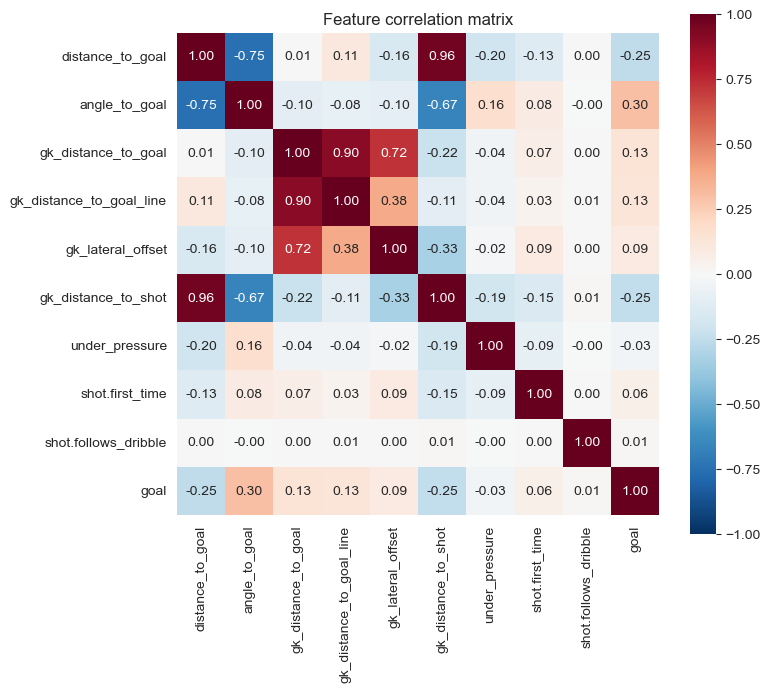

In [19]:
num_cols = [
    'distance_to_goal', 'angle_to_goal',
    'gk_distance_to_goal', 'gk_distance_to_goal_line',
    'gk_lateral_offset', 'gk_distance_to_shot',
    'under_pressure', 'shot.first_time', 'shot.follows_dribble',
    'goal',
]
corr = shots[num_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Feature correlation matrix')
plt.tight_layout(); plt.show()


**Read the last row (`goal`) to see what's correlated with the label**:

- `distance_to_goal` should have the largest negative correlation
- `angle_to_goal` positive
- GK features should be small individually but non-zero — that's the novelty
  signal we'll amplify with non-linear models.

**Watch for cross-feature redundancy**:
- `gk_distance_to_goal` and `gk_distance_to_goal_line` will be near-identical
  when the GK is centered. We may drop one in the final model.
- `gk_distance_to_shot` ≈ `distance_to_goal` minus `gk_distance_to_goal_line`.


---
## §6 Takeaways → modeling implications

Concrete decisions for the next notebook (`03_feature_engineering` /
`04_modeling`):

| Finding | Modeling implication |
|---|---|
| Goal rate decays non-linearly with distance | Logistic regression baseline will under-fit; tree models will shine |
| Penalty shots are ~75% conversion | Flag `shot.type == 'Penalty'`; consider reporting metrics with/without |
| Body-part and technique have heterogeneous goal rates | One-hot encode both |
| `under_pressure`, `first_time`, `follows_dribble` all shift goal rate | Include as int features |
| GK location available for 98% of shots | Median-impute the missing 2% rather than dropping |
| GK off-line distance correlates with conversion (§4.2) | Keep `gk_distance_to_goal_line` and `gk_lateral_offset` |
| `gk_distance_to_shot` ≈ `distance_to_goal` minus offset | Watch redundancy in feature importance plots |
| Class is 89/11 imbalanced | Evaluate with AUC-ROC, log loss, Brier — **never** accuracy |
| Tree models tend to be miscalibrated | Apply Platt + isotonic post-hoc; compare calibration curves |

**Open question for §4 ablation:** does adding the GK feature tier improve
log loss / Brier on top of geometry + context features? The answer is the
core empirical claim of the paper.
